# Neutrino Oscillation Inference Pipeline — XGBoost Classifier

This notebook mirrors the neural-network inference pipeline, but uses the trained **XGBoost** IBD-vs-accidental classifier. It applies the model to real near- and far-detector events, estimates the accidental background with the time-shift method, subtracts it from the prompt-energy (\(E_p\)) spectra, and extracts the reactor mixing angle \(\theta_{13}\).

**Signal selection uses the raw classifier scores** (not the calibrated probabilities), consistently with the neural-network analysis, to avoid a selection-efficiency imbalance between detectors. The calibrated probabilities \(P_{sig}\) are still computed, but only as an input to the per-bin purity cross-check.

**Key difference from the NN pipeline:** the \(\theta_{13}\) uncertainty here also propagates the *classifier score uncertainty* provided by the XGBoost model (\(\sigma_{score}\)), combined with the accidental-background Poisson error, rather than relying on counting statistics alone.

**Workflow:** load model → load & pair events → estimate background → predict scores → select signal (raw score) → subtract background → extract \(\theta_{13}\) → propagate errors (model + background) → weighted mean, \(\chi^2\) fit, Poissonian fit → purity cross-check.

## Imports

In [77]:
import json
import joblib
import numpy as np
import pyarrow.parquet as pq
import xgboost as xgb
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit, minimize

from build_pairs import (
    compute_detector_geometry,
    build_real_pairs,
    generate_background_pairs,
    estimate_background_spectrum,
)


## Configuration

Paths, physics constants (baselines, mass splitting, IBD Q-value offset), and analysis parameters (score threshold, binning, background time shifts) are centralized here.

In [78]:
DATA_DIR = "---"
NEAR_DATA_PATH = DATA_DIR / "near.parquet"
FAR_DATA_PATH = DATA_DIR / "far.parquet"
MODEL_PATH = Path("xgb_ibd_model.json")
MODEL_META_PATH = Path("xgb_meta.json")
SCALER_PATH = Path("scaler.pkl")
XGB_SCORE_MEAN_PATH = Path("xgb_score_mean.npy")
XGB_SCORE_SIGMA_PATH = Path("xgb_score_sigma.npy")

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

#  Physics constants 
L_NEAR_M = 500.0            # Near-detector baseline [m]
L_FAR_M = 1648.0           # Far-detector baseline [m]
DM2_EV2 = 2.5e-3           # Atmospheric mass-squared splitting [eV^2]
HBAR_C_EV_M = 197.327e-9   # hbar*c [eV * m], sets the oscillation length scale
IBD_Q_OFFSET_EV = 0.8e6    # Ep -> E_nu conversion offset [eV]

#  Analysis parameters 
RANDOM_SEED = 42
MAX_DT_NS = 2e6                                 # Coincidence time window for pair building [ns]
BG_SHIFTS_NS = 1e6 * np.arange(-20, -10, 1)     # Temporal shifts used to estimate accidental background
SCORE_THRESHOLD = 0.7                           # XGB raw-score cut for signal selection
N_EP_BINS = 100                                 # Number of bins in the prompt-energy (Ep) histograms
MIN_FAR_COUNTS = 100                             # Minimum far-detector counts required per bin in the fit

#  Plot styling: slightly larger fonts for presentation readability 
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 15,
})

np.random.seed(RANDOM_SEED)


## Load Trained Classifier

In [79]:
scaler = joblib.load(SCALER_PATH)

model = xgb.XGBClassifier()
model.load_model(MODEL_PATH)

feature_cols = json.load(open(MODEL_META_PATH))["feature_cols"]


## Load Datasets and Build IBD Pairs

Real near/far events are loaded and paired into coincidence candidates (`build_real_pairs`), using the detector geometry inferred from the near-detector data. Columns not used as classifier features are dropped before scoring.

In [80]:
far_events = pq.read_table(FAR_DATA_PATH).to_pandas()
near_events = pq.read_table(NEAR_DATA_PATH).to_pandas()

R_DET, Z_MAX = compute_detector_geometry(near_events)

near_pairs = build_real_pairs(near_events, R_DET=R_DET, Z_MAX=Z_MAX, max_dt=MAX_DT_NS)
far_pairs = build_real_pairs(far_events, R_DET=R_DET, Z_MAX=Z_MAX, max_dt=MAX_DT_NS)

DROP_COLS = ["Ep", "E_sum", "E_diff", "theta_p", "theta_d", "p_time", "d_time", "rp", "rd", "E_div", "E_asym",]

X_near = near_pairs.drop(columns=DROP_COLS)[feature_cols]
X_far = far_pairs.drop(columns=DROP_COLS)[feature_cols]

print(f"Generated {X_near.shape[0]} near pairs")
print(f"Generated {X_far.shape[0]} far pairs")


Generated 201640 near pairs
Generated 108816 far pairs


## Accidental Background Estimation (Time-Shift Method)

The accidental coincidence rate is estimated by repeatedly shifting one leg of the pair in time and rebuilding pairs; genuine IBD coincidences do not survive an artificial time shift, so the resulting pair yield estimates the accidental background.

In [81]:
bg_dfs_near, shifts_used = generate_background_pairs(
    near_events,
    shifts=BG_SHIFTS_NS,
    R_DET=R_DET,
    Z_MAX=Z_MAX,
    max_dt=MAX_DT_NS,
    apply_transforms=True,  # apply the same feature transforms used at training time
)

bg_dfs_far, shifts_used = generate_background_pairs(
    far_events,
    shifts=BG_SHIFTS_NS,
    R_DET=R_DET,
    Z_MAX=Z_MAX,
    max_dt=MAX_DT_NS,
    apply_transforms=True,
)

print(f"Generated {len(bg_dfs_near)} near background datasets")
print(f"Pairs per shift (near): {[len(df) for df in bg_dfs_near]}")
print("------")
print(f"Generated {len(bg_dfs_far)} far background datasets")
print(f"Pairs per shift (far): {[len(df) for df in bg_dfs_far]}")

near_bkg_estim = np.mean([len(df) for df in bg_dfs_near])
far_bkg_estim = np.mean([len(df) for df in bg_dfs_far])


/Users/francesco/anaconda_projects/LCP-neutrino/.conda/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/francesco/anaconda_projects/LCP-neutrino/.conda/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/francesco/anaconda_projects/LCP-neutrino/.conda/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Generated 10 near background datasets
Pairs per shift (near): [101477, 101271, 101559, 101867, 101641, 101459, 101960, 101493, 101549, 102083]
------
Generated 10 far background datasets
Pairs per shift (far): [100202, 99995, 100185, 100307, 100234, 100264, 100221, 100094, 100063, 100130]


## Model Predictions

The XGBoost classifier outputs a signal score for each candidate pair. The noise-to-signal ratios \(\beta = N_{bkg}/N_{signal}\) are also computed here; they are used later only to build the calibrated probabilities \(P_{sig}\) entering the purity cross-check.

In [82]:
scaled_X_near = scaler.transform(X_near)
scaled_X_far = scaler.transform(X_far)

# Noise-to-signal ratios (needed only for the calibrated purity cross-check)
near_beta = near_bkg_estim / (X_near.shape[0] - near_bkg_estim)
far_beta = far_bkg_estim / (X_far.shape[0] - far_bkg_estim)

print(f"Near signal-to-noise ratio: {1 / near_beta:.3f}")
print(f"Far signal-to-noise ratio: {1 / far_beta:.3f}")

y_score_near = model.predict_proba(scaled_X_near)[:, 1]
y_score_far = model.predict_proba(scaled_X_far)[:, 1]


Near signal-to-noise ratio: 0.984
Far signal-to-noise ratio: 0.086


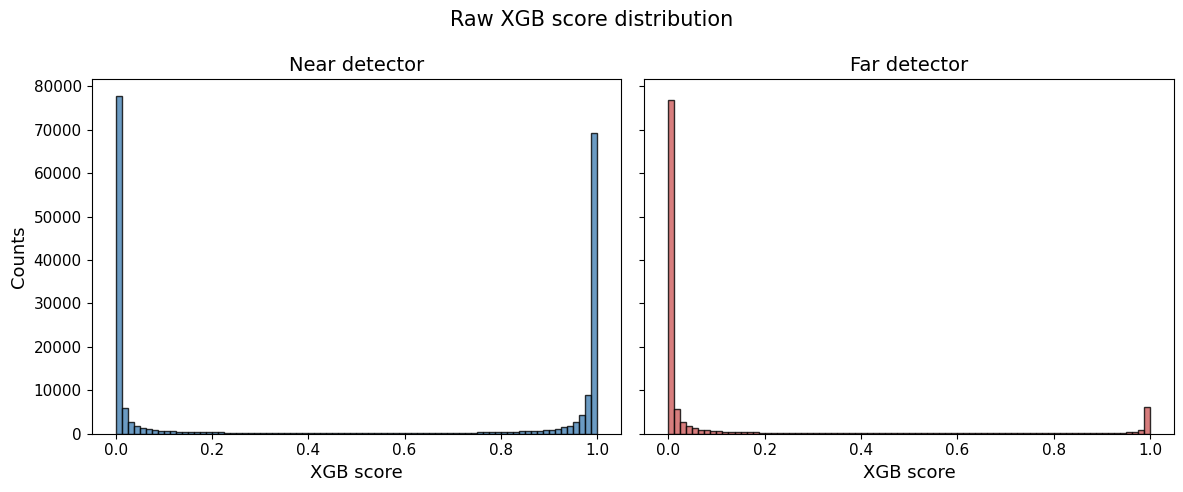

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].hist(y_score_near, bins=80, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Near detector")
axes[0].set_xlabel("XGB score")
axes[0].set_ylabel("Counts")

axes[1].hist(y_score_far, bins=80, color="indianred", edgecolor="black", alpha=0.8)
axes[1].set_title("Far detector")
axes[1].set_xlabel("XGB score")

fig.suptitle("Raw XGB score distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgb_score_raw.png", dpi=300, bbox_inches="tight")
plt.show()


The calibrated signal probability rescales the raw score for class imbalance via \(\beta\). It is shown here for reference and reused only in the purity section; **it is not used for signal selection**.

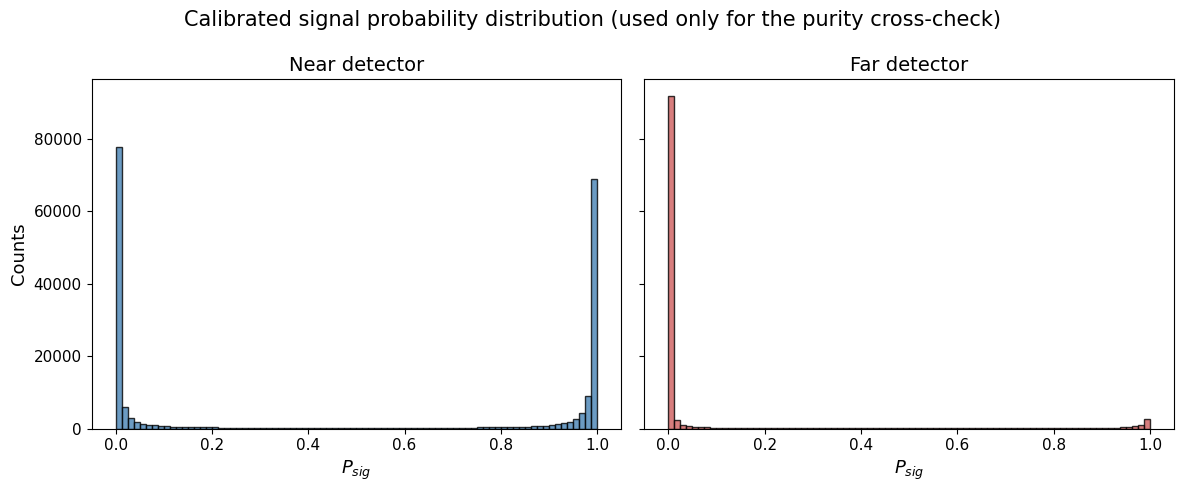

In [84]:
P_sig_near = y_score_near / (y_score_near + (1 - y_score_near) * near_beta)
P_sig_far = y_score_far / (y_score_far + (1 - y_score_far) * far_beta)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].hist(P_sig_near, bins=80, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Near detector")
axes[0].set_xlabel("$P_{sig}$")
axes[0].set_ylabel("Counts")

axes[1].hist(P_sig_far, bins=80, color="indianred", edgecolor="black", alpha=0.8)
axes[1].set_title("Far detector")
axes[1].set_xlabel("$P_{sig}$")

fig.suptitle("Calibrated signal probability distribution (used only for the purity cross-check)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "signal_probability_calibrated.png", dpi=300, bbox_inches="tight")
plt.show()


## Signal Selection

Signal is selected by thresholding the **raw XGB score**, consistently with the neural-network analysis.

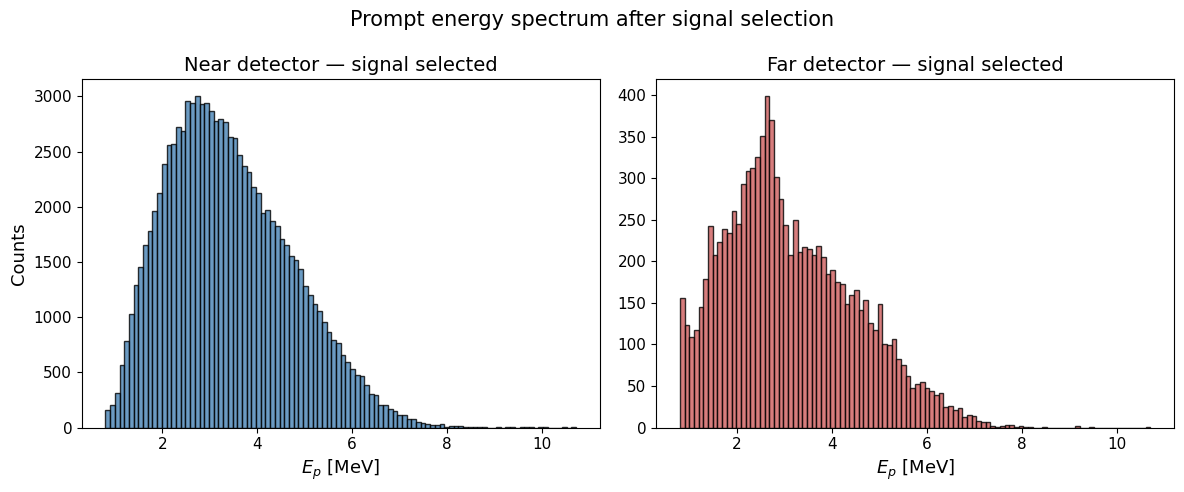

In [85]:
mask_signal_near = y_score_near > SCORE_THRESHOLD
mask_signal_far = y_score_far > SCORE_THRESHOLD

Ep_near = near_pairs["Ep"].to_numpy()[mask_signal_near]
Ep_far = far_pairs["Ep"].to_numpy()[mask_signal_far]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
axes[0].hist(Ep_near, bins=100, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Near detector — signal selected")
axes[0].set_xlabel("$E_p$ [MeV]")
axes[0].set_ylabel("Counts")

axes[1].hist(Ep_far, bins=100, color="indianred", edgecolor="black", alpha=0.8)
axes[1].set_title("Far detector — signal selected")
axes[1].set_xlabel("$E_p$ [MeV]")

fig.suptitle("Prompt energy spectrum after signal selection")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ep_spectrum_selected.png", dpi=300, bbox_inches="tight")
plt.show()


## Background Subtraction

The classifier is applied to every time-shifted background realization; the resulting selected-pair \(E_p\) spectra are averaged over shifts to obtain the accidental background estimate in each bin, which is then subtracted from the selected spectra. Background selection uses the same raw-score threshold as the signal.

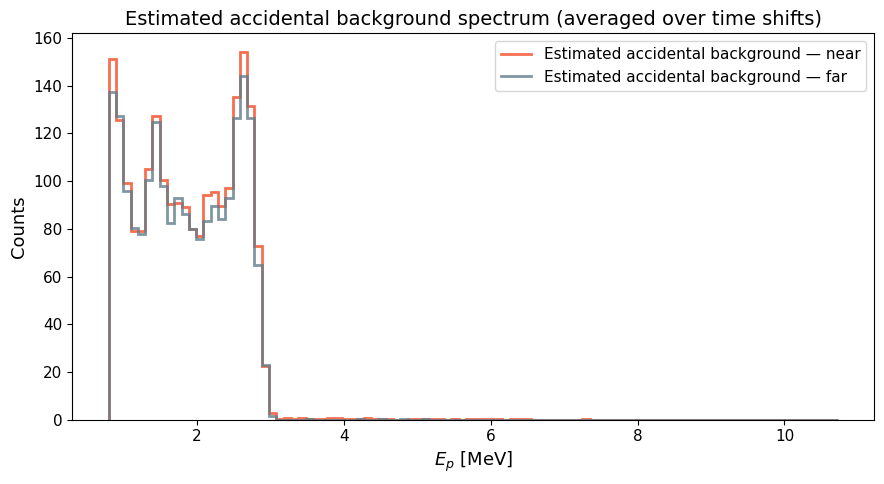

In [86]:
near_selected_bg = []
for df in bg_dfs_near:
    X_bg = df.drop(columns=DROP_COLS)[feature_cols]
    X_bg_scaled = scaler.transform(X_bg)
    bg_scores = model.predict_proba(X_bg_scaled)[:, 1]
    near_selected_bg.append(bg_scores > SCORE_THRESHOLD)

far_selected_bg = []
for df in bg_dfs_far:
    X_bg = df.drop(columns=DROP_COLS)[feature_cols]
    X_bg_scaled = scaler.transform(X_bg)
    bg_scores = model.predict_proba(X_bg_scaled)[:, 1]
    far_selected_bg.append(bg_scores > SCORE_THRESHOLD)

# Shared binning for signal, background, and subtracted spectra
bins_ep = np.linspace(float(Ep_near.min()), float(Ep_near.max()), N_EP_BINS + 1)
bin_centers = 0.5 * (bins_ep[:-1] + bins_ep[1:])

histo_near_background = estimate_background_spectrum(bg_dfs_near, near_selected_bg, bins=bins_ep, energy_col="Ep", norm_factor=1.0,)
histo_far_background = estimate_background_spectrum(bg_dfs_far, far_selected_bg, bins=bins_ep, energy_col="Ep", norm_factor=1.0,)

fig, ax = plt.subplots(figsize=(9, 5))
ax.stairs(histo_near_background, bins_ep, color="#F64B25", alpha=0.8, linewidth=2, label="Estimated accidental background — near")
ax.stairs(histo_far_background, bins_ep, color="#607D8B", alpha=0.8, linewidth=2, label="Estimated accidental background — far")
ax.set_xlabel("$E_p$ [MeV]")
ax.set_ylabel("Counts")
ax.set_title("Estimated accidental background spectrum (averaged over time shifts)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "background_spectrum.png", dpi=300, bbox_inches="tight")
plt.show()


In [87]:
histo_near_selected, _ = np.histogram(Ep_near, bins=bins_ep)
histo_far_selected, _ = np.histogram(Ep_far, bins=bins_ep)

histo_near_subtracted = histo_near_selected - histo_near_background
histo_far_subtracted = histo_far_selected - histo_far_background

# Per-bin Poisson uncertainties on the selected, background, and subtracted spectra
n_shifts = len(bg_dfs_near)
err_near_selected = np.sqrt(histo_near_selected)
err_far_selected = np.sqrt(histo_far_selected)
err_near_background = np.sqrt(histo_near_background / n_shifts)
err_far_background = np.sqrt(histo_far_background / n_shifts)

err_near_subtracted = np.sqrt(err_near_selected**2 + err_near_background**2)
err_far_subtracted = np.sqrt(err_far_selected**2 + err_far_background**2)


### Near Detector

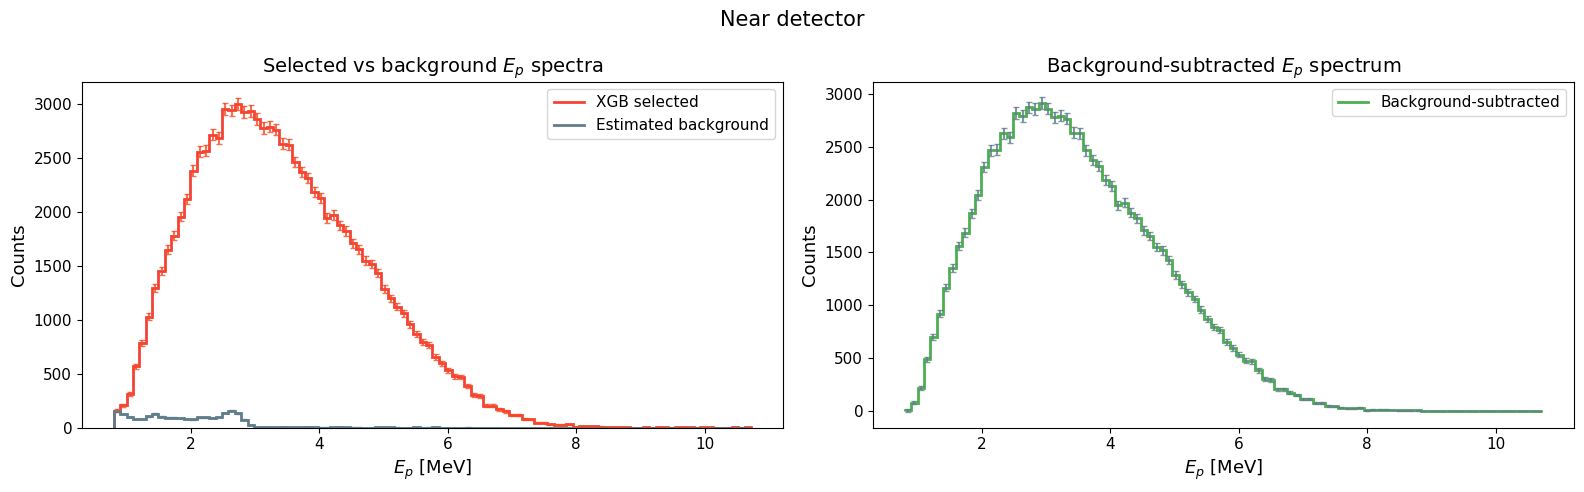

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.stairs(histo_near_selected, bins_ep, label="XGB selected", color="#F44336", linewidth=2)
ax.stairs(histo_near_background, bins_ep, label="Estimated background", color="#607D8B", linewidth=2)
ax.errorbar(bin_centers, histo_near_selected, yerr=err_near_selected, fmt="none", ecolor="#F64B25", capsize=2, alpha=0.8)
ax.errorbar(bin_centers, histo_near_background, yerr=err_near_background, fmt="none", ecolor="#607D8B", capsize=2, alpha=0.8)
ax.set_xlabel("$E_p$ [MeV]")
ax.set_ylabel("Counts")
ax.set_title("Selected vs background $E_p$ spectra")
ax.legend()

ax = axes[1]
ax.stairs(histo_near_subtracted, bins_ep, label="Background-subtracted", color="#4CAF50", linewidth=2)
ax.errorbar(bin_centers, histo_near_subtracted, yerr=err_near_subtracted, fmt="none", ecolor="#607D8B", capsize=2, alpha=0.8)
ax.set_xlabel("$E_p$ [MeV]")
ax.set_ylabel("Counts")
ax.set_title("Background-subtracted $E_p$ spectrum")
ax.legend()

fig.suptitle("Near detector")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ep_spectrum_near.png", dpi=300, bbox_inches="tight")
plt.show()


### Far Detector

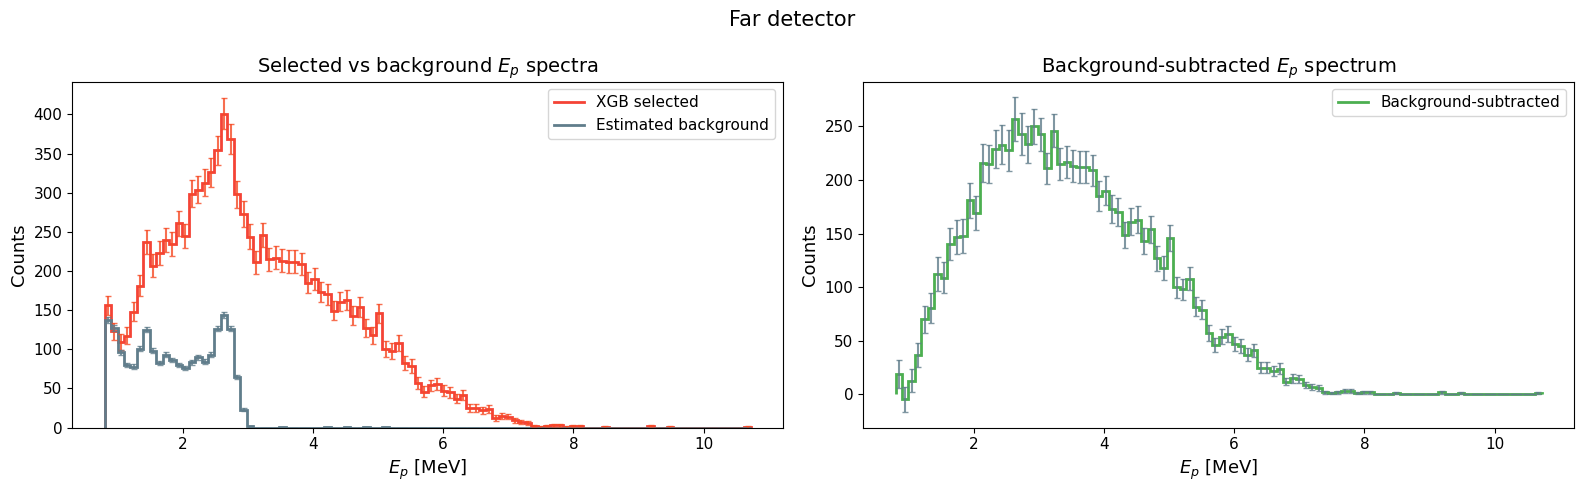

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.stairs(histo_far_selected, bins_ep, label="XGB selected", color="#F44336", linewidth=2)
ax.stairs(histo_far_background, bins_ep, label="Estimated background", color="#607D8B", linewidth=2)
ax.errorbar(bin_centers, histo_far_selected, yerr=err_far_selected, fmt="none", ecolor="#F64B25", capsize=2, alpha=0.8)
ax.errorbar(bin_centers, histo_far_background, yerr=err_far_background, fmt="none", ecolor="#607D8B", capsize=2, alpha=0.8)
ax.set_xlabel("$E_p$ [MeV]")
ax.set_ylabel("Counts")
ax.set_title("Selected vs background $E_p$ spectra")
ax.legend()

ax = axes[1]
ax.stairs(histo_far_subtracted, bins_ep, label="Background-subtracted", color="#4CAF50", linewidth=2)
ax.errorbar(bin_centers, histo_far_subtracted, yerr=err_far_subtracted, fmt="none", ecolor="#607D8B", capsize=2, alpha=0.8)
ax.set_xlabel("$E_p$ [MeV]")
ax.set_ylabel("Counts")
ax.set_title("Background-subtracted $E_p$ spectrum")
ax.legend()

fig.suptitle("Far detector")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ep_spectrum_far.png", dpi=300, bbox_inches="tight")
plt.show()


## \(\theta_{13}\) Extraction — Bin-by-Bin Estimate

For each \(E_p\) bin, the far/near ratio of background-subtracted counts gives a direct estimate of the disappearance probability, which is then inverted bin-by-bin for \(\theta_{13}\).

In [90]:
def compute_osc_probability(hist_near, hist_far):
    """Disappearance probability 1 - (N_far/N_near) * (L_far/L_near)^2 from the raw far/near ratio."""
    hist_near = hist_near.astype(float)
    hist_far = hist_far.astype(float)

    n_frac = np.divide(hist_far, hist_near, out=np.zeros_like(hist_far), where=hist_near > 0)
    p_osc = (L_FAR_M / L_NEAR_M) ** 2 * n_frac

    # Mask bins with no statistics or an unphysical probability
    valid = (hist_near > 0) & (hist_far > 0) & (p_osc >= 0) & (p_osc <= 1)
    p_osc = 1.0 - np.where(valid, p_osc, np.nan)
    return p_osc


def compute_theta(bins, p_osc):
    """Invert the two-flavor disappearance formula sin^2(2*theta) for theta, per bin."""
    ep_centers_ev = 0.5 * (bins[:-1] + bins[1:]) * 1e6
    enu_centers_ev = ep_centers_ev + IBD_Q_OFFSET_EV
    phase_length = L_FAR_M / HBAR_C_EV_M  # eV^-1

    theta = 0.5 * np.arcsin(np.sqrt(p_osc) / np.sin(DM2_EV2 * phase_length / (4 * enu_centers_ev)))
    return theta


In [91]:
P = compute_osc_probability(histo_near_subtracted, histo_far_subtracted)
print(P)


[           nan            nan 3.42824532e-01 1.80776498e-01
            nan 5.14955662e-02            nan 1.25261030e-01
 2.20864997e-02 5.34072304e-02 1.40648871e-01 3.83690026e-02
 2.03516844e-01 5.04955747e-02 5.79537387e-02 5.54275257e-02
 2.33350588e-02 1.23007387e-01 3.61964656e-04 8.31992761e-02
 1.14391519e-01 6.82046180e-02 7.92902247e-02 1.75666927e-01
 4.32986554e-02 1.55148144e-01 1.05111539e-01 1.19780847e-01
 6.62910111e-02 2.92984102e-02 1.89700380e-02 7.95232390e-02
 3.03987974e-02 3.46180563e-02 6.38898624e-02 1.36842754e-01
 4.14106237e-02            nan 6.06499649e-02            nan
 9.31491055e-02 1.04626187e-01            nan 9.53778125e-02
 5.09588447e-02            nan 7.01289019e-02 1.09189075e-02
 2.17160415e-01 3.48296380e-01 1.01079890e-01            nan
 4.36599513e-02            nan 1.44779166e-01            nan
 1.09247622e-01 7.59088125e-02            nan            nan
 2.37640982e-01            nan            nan 1.34756248e-01
 3.74011139e-02 1.297503

In [92]:
theta = compute_theta(bins_ep, P)
print(theta)


[       nan        nan        nan 0.63381391        nan 0.17789676
        nan 0.23138842 0.08844489 0.13191406 0.21012109 0.10439572
 0.24331936 0.11578272 0.12290872 0.1193496  0.07674565 0.17917608
 0.00952598 0.14697274 0.17415331 0.13415801 0.14598953 0.22327136
 0.10899589 0.21299567 0.17532252 0.18977748 0.1411734  0.09419838
 0.07650812 0.16059937 0.09940363 0.1074683  0.14881561 0.22469344
 0.12216235        nan 0.15234911        nan 0.19545397 0.21056819
        nan 0.20573754 0.15021223        nan 0.18180012 0.07125284
 0.34788487 0.48196732 0.2321345         nan 0.15299364        nan
 0.29799846        nan 0.26111402 0.21699198        nan        nan
 0.43871051        nan        nan 0.32064565 0.16209068 0.32148817
        nan        nan 0.56188658        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan       

/var/folders/k_/4mk26lc17c1_f33q7r45t8f80000gn/T/ipykernel_13126/2875004591.py:21: RuntimeWarning: invalid value encountered in arcsin
  theta = 0.5 * np.arcsin(


In [93]:
stats_mask = histo_far_subtracted >= MIN_FAR_COUNTS

bin_low = bins_ep[:-1]
bin_high = bins_ep[1:]

theta_cut = theta[stats_mask]
low_cut = bin_low[stats_mask]
high_cut = bin_high[stats_mask]

n_sel, n_tot = stats_mask.sum(), stats_mask.size
print(f"Selected bins: {n_sel}/{n_tot}")
print(f"Energy range (Ep, MeV): [{low_cut.min():.3f}, {high_cut.max():.3f}]")

# Check that selected bins are contiguous, otherwise the quoted energy range is misleading
sel_idx = np.flatnonzero(stats_mask)
gaps = np.where(np.diff(sel_idx) > 1)[0]
if gaps.size:
    print(f"Warning: selection is NOT contiguous — gap(s) after bin(s) {sel_idx[gaps]}")
else:
    print("Selection is contiguous.")

print()
print(theta_cut)
theta_mean = theta_cut[~np.isnan(theta_cut)].mean()
print(f"Mean theta over selected bins: {theta_mean:.4f} rad")


Selected bins: 38/100
Energy range (Ep, MeV): [1.396, 5.365]

[       nan 0.23138842 0.08844489 0.13191406 0.21012109 0.10439572
 0.24331936 0.11578272 0.12290872 0.1193496  0.07674565 0.17917608
 0.00952598 0.14697274 0.17415331 0.13415801 0.14598953 0.22327136
 0.10899589 0.21299567 0.17532252 0.18977748 0.1411734  0.09419838
 0.07650812 0.16059937 0.09940363 0.1074683  0.14881561 0.22469344
 0.12216235        nan 0.15234911        nan 0.19545397 0.21056819
        nan        nan]
Mean theta over selected bins: 0.1478 rad


## Error Propagation (Model Score + Poisson)

The \\(\\theta_{13}\\) uncertainty is propagated from three contributions to the per-bin signal counts:

- **Classifier score uncertainty:** each selected event carries the XGBoost score uncertainty \\(\\sigma_{score}\\); these add in quadrature within each energy bin (a weighted histogram error). *This is the term specific to the XGBoost analysis.*
- **Signal counting statistics:** the Poisson error \\(\\sqrt{N_{sel}}\\) on the selected counts per bin.
- **Accidental-background uncertainty:** the Poisson error \\(\\sqrt{N_{bkg}}\\) on the subtracted background per bin.

These combine into a per-bin signal uncertainty, which is propagated through the far/near ratio into \\(\\sigma_P\\), and finally through the analytic \\(\\theta(P,E)\\) derivatives (plus the bin-width contribution to the energy) into \\(\\sigma_\\theta\\).


The XGB score uncertainty is treated as an approximation: the model was trained on a balanced dataset, so the reported variance is strictly valid for the near-detector working point and does not capture the signal/background proportion bias. As a sanity check, we verify that only a small fraction of events lie within one \(\sigma_{score}\) of the decision threshold, so the working point is stable against the score uncertainty.

In [94]:
xgb_score_mean = np.load(XGB_SCORE_MEAN_PATH)
xgb_score_sigma = np.load(XGB_SCORE_SIGMA_PATH)

# Fraction of events whose score lies within one sigma of the decision threshold
margin = np.abs(xgb_score_mean - SCORE_THRESHOLD)
fraction_near_threshold = np.mean(margin < xgb_score_sigma)
print(f"Fraction of events within 1 sigma of the threshold: {fraction_near_threshold:.4f}")

sigma_score_model = xgb_score_sigma.mean()  # scalar approximation (no per-event near/far split)
print(f"Mean XGB score uncertainty: {sigma_score_model:.4f}")


Fraction of events within 1 sigma of the threshold: 0.0105
Mean XGB score uncertainty: 0.0067


In [95]:
def weighted_hist_error(energy, sigma_weight, bins):
    """Per-bin sigma from events falling in the bin: sqrt(sum_i sigma_i^2)."""
    variance = np.histogram(energy, bins=bins, weights=sigma_weight**2)[0]
    return np.sqrt(variance)



# Three terms in quadrature:
#   sigma_ml   : XGBoost score uncertainty (XGB-specific term)
#   err_selected : Poisson statistics on the selected counts (sqrt(N_sel))
#   sigma_bkg  : Poisson statistics on the subtracted background (sqrt(N_bkg))
sigma_ml_near = weighted_hist_error(Ep_near, sigma_score_model * np.ones(Ep_near.size), bins_ep)
sigma_ml_far = weighted_hist_error(Ep_far, sigma_score_model * np.ones(Ep_far.size), bins_ep)

sigma_bkg_near = err_near_background
sigma_bkg_far = err_far_background

sigma_signal_near = np.sqrt(sigma_ml_near**2 + err_near_selected**2 + sigma_bkg_near**2)
sigma_signal_far = np.sqrt(sigma_ml_far**2 + err_far_selected**2 + sigma_bkg_far**2)

#  Analytic theta(P, E) derivatives 
enu_centers_ev = 0.5 * (bins_ep[:-1] + bins_ep[1:]) * 1e6 + IBD_Q_OFFSET_EV
phase_length = L_FAR_M / HBAR_C_EV_M  # eV^-1
phi = DM2_EV2 * phase_length / (4 * enu_centers_ev)
sin_phi = np.sin(phi)
cos_phi = np.cos(phi)

P_osc = np.clip(P, 0, None)
x = np.sqrt(P_osc) / sin_phi
valid = (P_osc > 0) & (np.abs(x) < 1)  # physical validity: P>0 and |arcsin arg| < 1
x_clip = np.where(valid, x, 0.0)
root = np.sqrt(np.maximum(1.0 - x_clip**2, 1e-15))

dtheta_dP = np.zeros_like(P_osc)
dtheta_dE = np.zeros_like(P_osc)
dtheta_dP[valid] = 1.0 / (4.0 * root[valid] * np.sqrt(P_osc[valid]) * sin_phi[valid])
dtheta_dE[valid] = (np.sqrt(P_osc[valid]) * cos_phi[valid] / sin_phi[valid] ** 2 * (DM2_EV2 * phase_length / enu_centers_ev[valid] ** 2) / (8.0 * root[valid]))

# --- Uncertainty on P from the far/near ratio, and on E from the bin width ---
S_near = histo_near_subtracted.astype(float)
S_far = histo_far_subtracted.astype(float)
safe_near = np.maximum(np.abs(S_near), 1e-9)
safe_far = np.maximum(np.abs(S_far), 1e-9)

sigma_P = np.abs(1-P_osc) * np.sqrt((sigma_signal_near / safe_near) ** 2 + (sigma_signal_far / safe_far) ** 2)
sigma_E = (bins_ep[1] - bins_ep[0]) * 1e6 / np.sqrt(12)  # eV

sigma_theta = np.where(valid, np.sqrt((dtheta_dP * sigma_P) ** 2 + (dtheta_dE * sigma_E) ** 2), np.nan)

# Aliases used by the fit sections below (mirror the NN notebook naming)
err_P = sigma_P
err_theta = sigma_theta

print(f"Mean theta over selected bins: {theta_mean:.4f} rad")
print(f"Mean sigma_theta over valid bins: {np.nanmean(sigma_theta):.4f} rad")
print(f"Valid bins: {valid.sum()} / {len(valid)}")


Mean theta over selected bins: 0.1478 rad
Mean sigma_theta over valid bins: 0.2081 rad
Valid bins: 51 / 100


## Weighted Mean of \(\theta_{13}\)

The per-bin \(\theta_{13}\) estimates over the selected bins are combined with inverse-variance weights.

In [96]:
err_theta_cut = err_theta[stats_mask]

valid_cut = ~np.isnan(theta_cut) & np.isfinite(err_theta_cut) & (err_theta_cut > 0)

theta_sel = theta_cut[valid_cut]
err_theta_sel = err_theta_cut[valid_cut]

weights = 1.0 / err_theta_sel**2
theta_mean_weighted = np.sum(weights * theta_sel) / np.sum(weights)
err_theta_mean_weighted = np.sqrt(1.0 / np.sum(weights))

print(f"Weighted mean theta over selected bins: {theta_mean_weighted:.6f} rad")
print(f"Error on the weighted mean: {err_theta_mean_weighted:.6f} rad")


Weighted mean theta over selected bins: 0.175564 rad
Error on the weighted mean: 0.012897 rad


## Non-linear \(\chi^2\) Fit for \(\theta_{13}\)

As a cross-check, \(\theta_{13}\) is extracted by fitting the analytic two-flavor disappearance formula \(P(E) = \sin^2(2\theta)\sin^2(\eta/E)\) directly to the binned probabilities, weighted by their propagated errors \(\sigma_P\).

Theta from non-linear fit: 0.156000 ± 0.012656 rad
sin^2(2*theta) = 0.094226


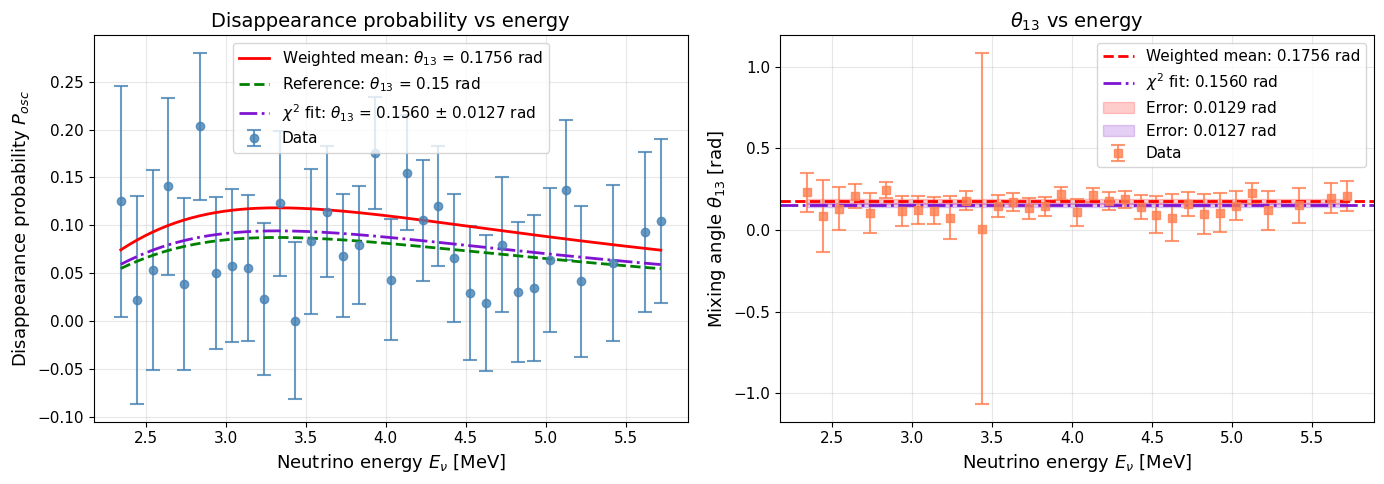

In [97]:
Ep_cut = enu_centers_ev[stats_mask][valid_cut]
P_cut = P[stats_mask][valid_cut]
err_P_cut = err_P[stats_mask][valid_cut]


def prob_oscillation(E, theta, dm2=DM2_EV2, L_far=L_FAR_M):
    """Two-flavor disappearance probability P_ee(E) = sin^2(2*theta) * sin^2(eta/E)."""
    eta_local = dm2 * L_far / (4 * HBAR_C_EV_M)  # eV^-1
    return np.sin(2 * theta) ** 2 * np.sin(eta_local / E) ** 2


p0 = [0.15]  # initial guess for theta
try:
    popt, pcov = curve_fit(prob_oscillation, Ep_cut, P_cut, p0=p0, sigma=err_P_cut, absolute_sigma=True, maxfev=10000,)
    theta_fit = popt[0]
    err_theta_fit = np.sqrt(pcov[0, 0])

    print(f"Theta from non-linear fit: {theta_fit:.6f} \u00b1 {err_theta_fit:.6f} rad")
    print(f"sin^2(2*theta) = {np.sin(2 * theta_fit) ** 2:.6f}")
except RuntimeError as e:
    print(f"Fit failed: {e}")
    theta_fit = None

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: disappearance probability vs energy
ax1.errorbar(Ep_cut * 1e-6, P_cut, yerr=err_P_cut, fmt="o", capsize=5, capthick=1.5,  markersize=6, color="steelblue", ecolor="steelblue", elinewidth=1.5,alpha=0.8, label="Data")

E_smooth = np.linspace(Ep_cut.min(), Ep_cut.max(), 200)
P_inferred = prob_oscillation(E_smooth, theta_mean_weighted)
P_theory = prob_oscillation(E_smooth, 0.15)
P_fit = prob_oscillation(E_smooth, theta_fit)

ax1.plot(E_smooth * 1e-6, P_inferred, "r-", linewidth=2, label=f"Weighted mean: $\\theta_{{13}}$ = {theta_mean_weighted:.4f} rad")
ax1.plot(E_smooth * 1e-6, P_theory, "g--", linewidth=2, label="Reference: $\\theta_{13}$ = 0.15 rad")
ax1.plot(E_smooth * 1e-6, P_fit, "-.", color="#7e14d0", linewidth=2, zorder=2, label=f"$\\chi^2$ fit: $\\theta_{{13}}$ = {theta_fit:.4f} \u00b1 {err_theta_fit:.4f} rad")

ax1.set_xlabel("Neutrino energy $E_\\nu$ [MeV]")
ax1.set_ylabel("Disappearance probability $P_{osc}$")
ax1.set_title("Disappearance probability vs energy")
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Panel 2: theta vs energy
ax2.errorbar(Ep_cut * 1e-6, theta_sel, yerr=err_theta_sel, fmt="s", capsize=5, capthick=1.5, markersize=6, color="coral", ecolor="coral", elinewidth=1.5, alpha=0.8, label="Data")
ax2.axhline(theta_mean_weighted, color="red", linestyle="--", linewidth=2, label=f"Weighted mean: {theta_mean_weighted:.4f} rad")
ax2.axhline(theta_fit, color="#7e14d0", linestyle="-.", linewidth=2, label=f"$\\chi^2$ fit: {theta_fit:.4f} rad")
ax2.fill_between(Ep_cut * 1e-6, theta_mean_weighted - err_theta_mean_weighted, theta_mean_weighted + err_theta_mean_weighted, alpha=0.2, color="red", label=f"Error: {err_theta_mean_weighted:.4f} rad")
ax2.fill_between(Ep_cut * 1e-6, theta_fit - err_theta_fit, theta_fit + err_theta_fit, alpha=0.2, color="#7e14d0", label=f"Error: {err_theta_fit:.4f} rad")
ax2.set_xlabel("Neutrino energy $E_\\nu$ [MeV]")
ax2.set_ylabel("Mixing angle $\\theta_{13}$ [rad]")
ax2.set_title("$\\theta_{13}$ vs energy")
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "theta13_chi2_fit.png", dpi=300, bbox_inches="tight")
plt.show()


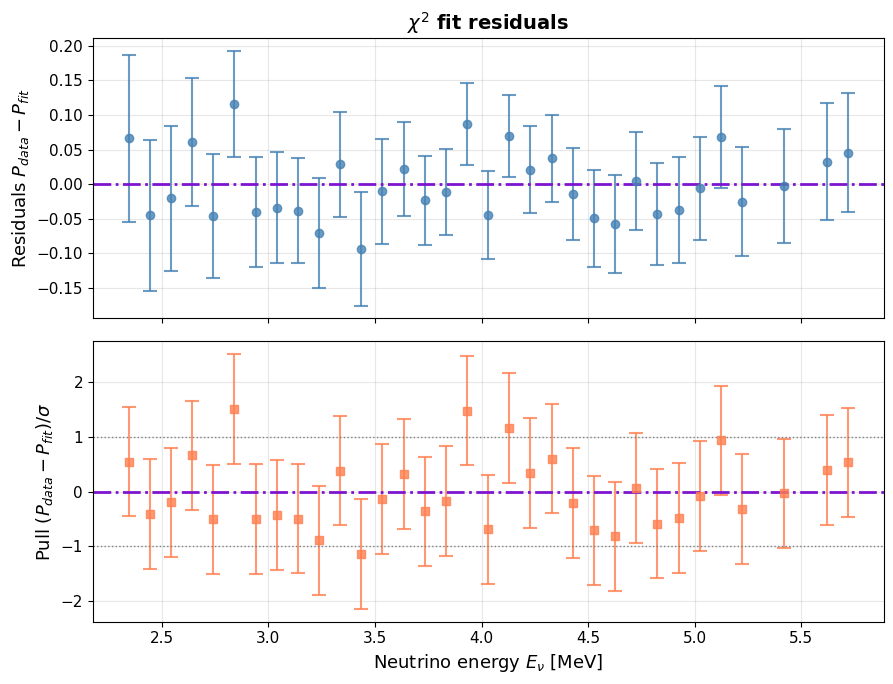

Chi2 = 14.39, ndof = 32, Chi2/ndof = 0.450


In [98]:
P_model_at_data = prob_oscillation(Ep_cut, theta_fit)
residuals = P_cut - P_model_at_data
pulls = residuals / err_P_cut

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True, gridspec_kw={"height_ratios": [1, 1]})

ax1.errorbar(Ep_cut * 1e-6, residuals, yerr=err_P_cut, fmt="o", capsize=5, capthick=1.5, markersize=6, color="steelblue", ecolor="steelblue", elinewidth=1.5, alpha=0.8)
ax1.axhline(0, color="#7e14d0", linestyle="-.", linewidth=2, zorder=2)
ax1.set_ylabel("Residuals $P_{data} - P_{fit}$")
ax1.set_title("$\\chi^2$ fit residuals", fontweight="bold")
ax1.grid(True, alpha=0.3)

ax2.errorbar(Ep_cut * 1e-6, pulls, yerr=1.0, fmt="s", capsize=5, capthick=1.5, markersize=6, color="coral", ecolor="coral", elinewidth=1.5, alpha=0.8)
ax2.axhline(0, color="#7e14d0", linestyle="-.", linewidth=2, zorder=2)
ax2.axhline(1, color="gray", linestyle=":", linewidth=1)
ax2.axhline(-1, color="gray", linestyle=":", linewidth=1)
ax2.set_xlabel("Neutrino energy $E_\\nu$ [MeV]")
ax2.set_ylabel("Pull $(P_{data}-P_{fit})/\\sigma$")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "theta13_chi2_fit_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

chi2 = np.sum(pulls**2)
ndof = len(P_cut) - 1  # one free parameter (theta)
print(f"Chi2 = {chi2:.2f}, ndof = {ndof}, Chi2/ndof = {chi2 / ndof:.3f}")


## Poissonian Likelihood Fit (\(\theta\), \(\kappa\) Free)

As a further cross-check, \(\theta_{13}\) and an overall near/far normalization factor \(\kappa\) are extracted jointly via a Poissonian maximum-likelihood fit of the far-detector counts, given the near-detector counts as the reference spectrum.

Bins used in the fit: 91/100
Theta (Poisson fit): 0.168435 rad
Kappa (Poisson fit): 1.024752
-2lnL at minimum: -66593.506
Converged: True, CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Theta = 0.168435 ± 0.040459 rad
Kappa = 1.024752 ± 0.046779
sin^2(2*theta) = 0.109253


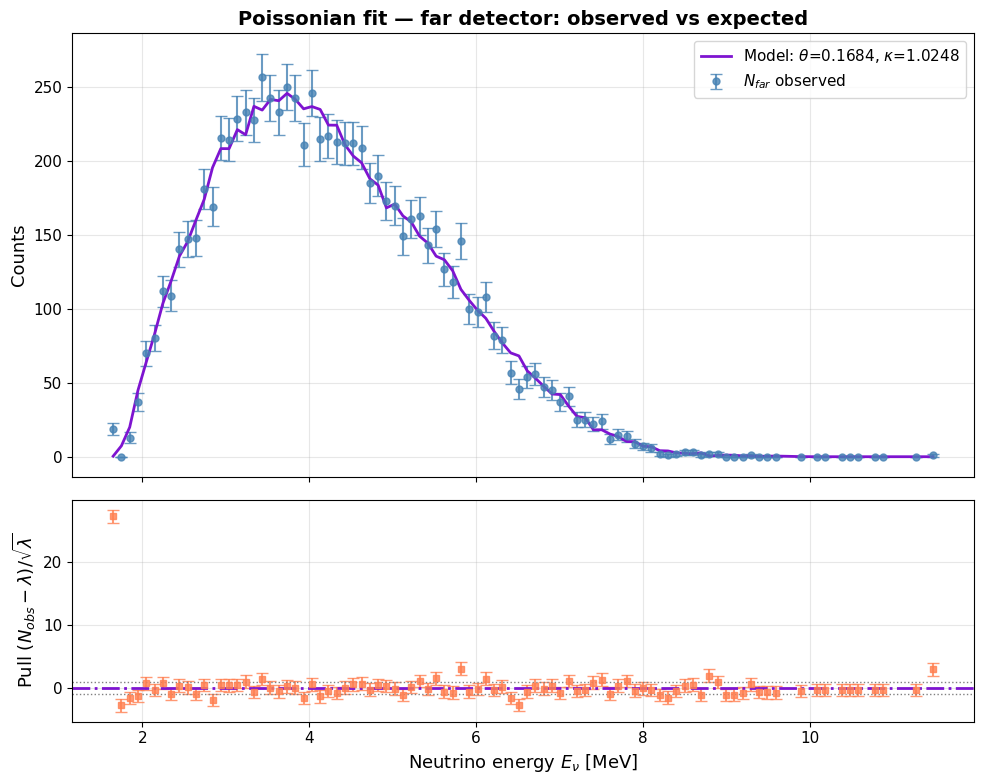


Chi2-equivalent = 833.15, ndof = 89, Chi2/ndof = 9.361


In [99]:
# Background-subtracted counts, clipped at zero (negative fluctuations are unphysical)
N_near = np.clip(histo_near_subtracted, 0, None)
N_far = np.clip(histo_far_subtracted, 0, None)

E_bins = enu_centers_ev  # reuse the neutrino energy bin centers computed above

# Exclude bins with zero near-detector counts (no information, avoids log(0))
valid_fit = N_near > 0
print(f"Bins used in the fit: {valid_fit.sum()}/{len(valid_fit)}")

FL = (L_NEAR_M / L_FAR_M) ** 2


def survival_prob(E, theta, dm2=DM2_EV2, L_far=L_FAR_M):
    return 1.0 - prob_oscillation(E, theta, dm2, L_far)


def lambda_far(theta, kappa, E, n_near_bins, fl):
    """Expected far-detector counts given the near-detector spectrum."""
    return kappa * fl * n_near_bins * survival_prob(E, theta)


def neg_log_likelihood(params):
    """Poissonian -2 ln L for the far-detector counts."""
    theta, kappa = params
    if kappa <= 0:
        return np.inf  # kappa must be positive on physical grounds

    lam = lambda_far(theta, kappa, E_bins[valid_fit], N_near[valid_fit], FL)
    lam_safe = np.clip(lam, 1e-12, None)  # avoid log(0)
    n_obs = N_far[valid_fit]

    return -2.0 * np.sum(n_obs * np.log(lam_safe) - lam_safe)


p0 = [0.15, 1.0]  # initial guess: theta, kappa

result = minimize(neg_log_likelihood, x0=p0, method="L-BFGS-B", bounds=[(1e-4, np.pi / 4), (1e-3, 10.0)])

theta_fit_poisson, kappa_fit_poisson = result.x
nll_min = result.fun

print(f"Theta (Poisson fit): {theta_fit_poisson:.6f} rad")
print(f"Kappa (Poisson fit): {kappa_fit_poisson:.6f}")
print(f"-2lnL at minimum: {nll_min:.3f}")
print(f"Converged: {result.success}, {result.message}")


def hessian_finite_diff(f, x, eps=1e-5):
    """Numerical Hessian via central finite differences."""
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            x_pp = x.copy(); x_pp[i] += eps; x_pp[j] += eps
            x_pm = x.copy(); x_pm[i] += eps; x_pm[j] -= eps
            x_mp = x.copy(); x_mp[i] -= eps; x_mp[j] += eps
            x_mm = x.copy(); x_mm[i] -= eps; x_mm[j] -= eps
            H[i, j] = (f(x_pp) - f(x_pm) - f(x_mp) + f(x_mm)) / (4 * eps**2)
    return H


# Hessian of neg_log_likelihood = -2lnL -> Fisher information = H/2;
# the parameter covariance matrix is the inverse of the Fisher information.
H_nll = hessian_finite_diff(neg_log_likelihood, result.x)
fisher_info = H_nll / 2.0
cov_matrix = np.linalg.inv(fisher_info)

err_theta_poisson = np.sqrt(cov_matrix[0, 0])
err_kappa_poisson = np.sqrt(cov_matrix[1, 1])

print(f"\nTheta = {theta_fit_poisson:.6f} \u00b1 {err_theta_poisson:.6f} rad")
print(f"Kappa = {kappa_fit_poisson:.6f} \u00b1 {err_kappa_poisson:.6f}")
print(f"sin^2(2*theta) = {np.sin(2 * theta_fit_poisson) ** 2:.6f}")

# Diagnostic plot: observed vs expected far-detector counts, and Poisson residuals
lambda_best = lambda_far(theta_fit_poisson, kappa_fit_poisson, E_bins, N_near, FL)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

Ep_MeV = E_bins * 1e-6

ax1.errorbar(Ep_MeV[valid_fit], N_far[valid_fit], yerr=np.sqrt(N_far[valid_fit]), fmt="o", capsize=4, markersize=5, color="steelblue", ecolor="steelblue", alpha=0.8, label="$N_{far}$ observed")
ax1.plot(Ep_MeV[valid_fit], lambda_best[valid_fit], "-", color="#7e14d0", linewidth=2, label=f"Model: $\\theta$={theta_fit_poisson:.4f}, $\\kappa$={kappa_fit_poisson:.4f}")
ax1.set_ylabel("Counts")
ax1.set_title("Poissonian fit — far detector: observed vs expected", fontweight="bold")
ax1.legend()
ax1.grid(alpha=0.3)

lam_valid = np.clip(lambda_best[valid_fit], 1e-12, None)
pull_poisson = (N_far[valid_fit] - lam_valid) / np.sqrt(lam_valid)

ax2.errorbar(Ep_MeV[valid_fit], pull_poisson, yerr=1.0, fmt="s", capsize=4, markersize=5, color="coral", ecolor="coral", alpha=0.8)
ax2.axhline(0, color="#7e14d0", linestyle="-.", linewidth=2)
ax2.axhline(1, color="gray", linestyle=":", linewidth=1)
ax2.axhline(-1, color="gray", linestyle=":", linewidth=1)
ax2.set_xlabel("Neutrino energy $E_\\nu$ [MeV]")
ax2.set_ylabel("Pull $(N_{obs}-\\lambda)/\\sqrt{\\lambda}$")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "theta13_poisson_fit.png", dpi=300, bbox_inches="tight")
plt.show()

ndof = valid_fit.sum() - 2  # two free parameters: theta, kappa
chi2_equiv = np.sum(pull_poisson**2)
print(f"\nChi2-equivalent = {chi2_equiv:.2f}, ndof = {ndof}, Chi2/ndof = {chi2_equiv / ndof:.3f}")


## Signal Purity Estimation

Per-bin purity is estimated from the mean calibrated \(P_{sig}\) of the selected events, and cross-checked against the purity implied by the independent accidental-background estimate. This is the only place where the calibrated probabilities enter the analysis.

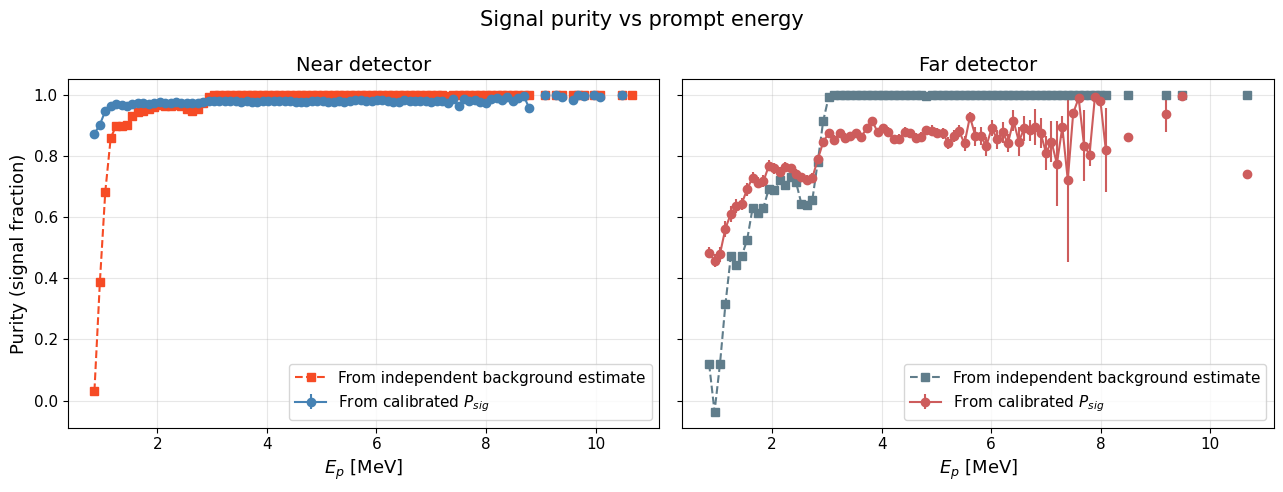

In [100]:
def purity_from_calibrated_prob(ep_selected, p_sig_selected, bins):
    bin_idx = np.digitize(ep_selected, bins) - 1
    n_bins = len(bins) - 1

    purity = np.full(n_bins, np.nan)
    err_purity = np.full(n_bins, np.nan)
    n_sel = np.zeros(n_bins, dtype=int)

    for i in range(n_bins):
        sel = bin_idx == i
        n = sel.sum()
        n_sel[i] = n
        if n > 0:
            vals = p_sig_selected[sel]
            purity[i] = vals.mean()
            if n > 1:
                err_purity[i] = vals.std(ddof=1) / np.sqrt(n)

    return purity, err_purity, n_sel


purity_near, err_purity_near, n_sel_near = purity_from_calibrated_prob(Ep_near, P_sig_near[mask_signal_near], bins_ep)
purity_far, err_purity_far, n_sel_far = purity_from_calibrated_prob(Ep_far, P_sig_far[mask_signal_far], bins_ep)

# Cross-check: purity implied by the independent accidental-background estimate
n_sig_near_hard = np.histogram(Ep_near, bins=bins_ep)[0]
purity_near_bkgcheck = 1.0 - np.divide(histo_near_background, n_sig_near_hard, out=np.full_like(histo_near_background, np.nan, dtype=float),where=n_sig_near_hard > 0,)

n_sig_far_hard = np.histogram(Ep_far, bins=bins_ep)[0]
purity_far_bkgcheck = 1.0 - np.divide(histo_far_background, n_sig_far_hard,out=np.full_like(histo_far_background, np.nan, dtype=float),where=n_sig_far_hard > 0,)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

axes[0].errorbar(bin_centers, purity_near, yerr=err_purity_near, fmt="o-", color="steelblue", label="From calibrated $P_{sig}$")
axes[0].plot(bin_centers, purity_near_bkgcheck, "s--", color="#F64B25", label="From independent background estimate")
axes[0].set_title("Near detector")
axes[0].set_xlabel("$E_p$ [MeV]")
axes[0].set_ylabel("Purity (signal fraction)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].errorbar(bin_centers, purity_far, yerr=err_purity_far, fmt="o-", color="indianred", label="From calibrated $P_{sig}$")
axes[1].plot(bin_centers, purity_far_bkgcheck, "s--", color="#607D8B", label="From independent background estimate")
axes[1].set_title("Far detector")
axes[1].set_xlabel("$E_p$ [MeV]")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Signal purity vs prompt energy")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "purity_vs_ep.png", dpi=300, bbox_inches="tight")
plt.show()


## Conclusions

Using the XGBoost classifier with raw-score signal selection, \(\theta_{13}\) is extracted with three consistent methods — bin-by-bin inversion, a non-linear \(\chi^2\) fit, and a joint Poissonian likelihood fit of \(\theta\) and the near/far normalization \(\kappa\) — matching the estimators used in the neural-network analysis for direct comparison. The distinctive feature of the XGBoost error budget is the inclusion of the classifier score uncertainty, added in quadrature with the signal and background Poisson counting errors in the per-bin signal uncertainty. Per-bin signal purity, cross-checked against the independent background estimate, supports the validity of the selection and background-subtraction procedure.